<a href="https://colab.research.google.com/github/TEC-A01800371/Reto---Entregas-en-Equipo/blob/main/Copia_de_sesion1_house_prices.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sesión 1 · Comprensión del problema y EDA inicial
## House Prices — Advanced Regression Techniques

| | |
|---|---|
| **Equipo** | Erik Owen Castro Flores, Juan Pablo Perez Gutierrez, Yael Michel Garcia Lopez, Alberto Gallegos Hernandez |
| **Fecha** | 17 de Agosto de 2026 |
| **Objetivo** | Primera exploración del dataset de House Prices: entender su estructura, identificar el target y detectar problemas iniciales en los datos. |

---

### ¿Cómo descargar el dataset?

1. Ve a [kaggle.com/competitions/house-prices-advanced-regression-techniques](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques)
2. Acepta las reglas de la competencia (necesitas cuenta de Kaggle).
3. Descarga `train.csv` desde la pestaña **Data**.
4. Colócalo en una carpeta `data/` en este proyecto.

```
tu_proyecto/
├── src/
|   └── sesion1_house_prices.ipynb   ← este archivo
└── data/
    └── train.csv
```

> 📌 **Convención del curso:** usa siempre rutas relativas (`./data/train.csv`), nunca rutas absolutas de tu computadora.

---
## PARTE 1
*Sigue los pasos junto con el profesor. En la Parte 2 trabajarás por tu cuenta.*

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 1.1 Importar librerías y cargar los datos

Importar las herramientas que vamos a usar y cargar el dataset.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Cargamos el dataset
df = pd.read_csv('/content/drive/MyDrive/house-prices-advanced-regression-techniques/train.csv')

print('Dataset cargado correctamente')

Dataset cargado correctamente


### 1.2 ¿Cuántos datos tenemos? → `.shape`

`.shape` devuelve una tupla `(filas, columnas)`. Las filas son observaciones (una casa cada una) y las columnas son variables (características de la casa).

In [ ]:
# Dimensiones del dataset: (observaciones, variables)
print('Dimensiones:', df.shape)
print(f'  → {df.shape[0]} casas (filas)')
print(f'  → {df.shape[1]} variables (columnas)')

Dimensiones: (1460, 81)
  → 1460 casas (filas)
  → 81 variables (columnas)


### 1.3 ¿Qué tipos de datos hay? → `.info()`

`.info()` muestra el **tipo de dato** de cada columna y cuántos **valores no nulos** tiene.
Un tipo `object` significa texto; `int64` o `float64` significa numérica.

> Si el conteo de no-nulos de una columna es menor que el total de filas, hay valores faltantes.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### 1.4 Estadísticas descriptivas → `.describe()`

`.describe()` resume las columnas **numéricas**: media, desviación estándar, mínimo, máximo y cuartiles (25%, 50%, 75%).

| Estadístico | Qué te dice |
|---|---|
| `mean` | Promedio — puede ser jalado por valores extremos |
| `std` | Qué tan dispersos están los valores |
| `min` / `max` | Rango — útil para detectar valores atípicos |
| `50%` | Mediana — más robusta que la media ante outliers |

In [ ]:
# Solo columnas numéricas por defecto
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### 1.5 ¿Hay valores faltantes? → `.isnull().sum()`

`.isnull()` genera un DataFrame de `True`/`False` (True donde hay nulo). `.sum()` los cuenta por columna.

Solo mostramos las columnas que sí tienen faltantes para no perdernos en las que no.

In [ ]:
nulos = df.isnull().sum()

# Filtramos solo las columnas con al menos 1 nulo
nulos_presentes = nulos[nulos > 0].sort_values(ascending=False)

print(f'Columnas con valores faltantes: {len(nulos_presentes)}')
print()
print(nulos_presentes.to_string())

Columnas con valores faltantes: 19

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1


### 1.6 Identificar la variable objetivo (target)

En este dataset el target es `SalePrice` — el precio de venta de la casa.

Veamos cómo se distribuye:

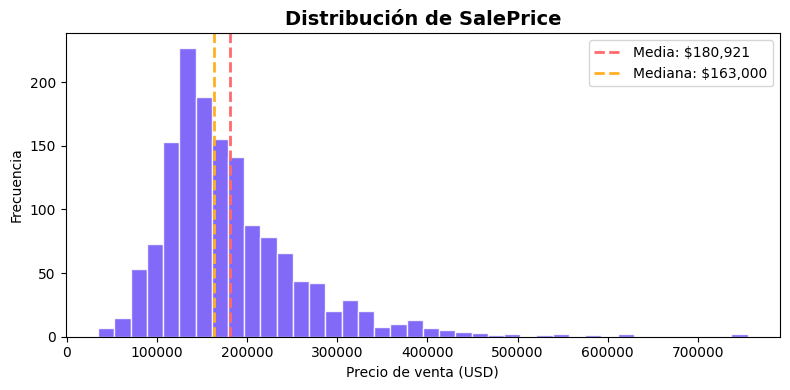

Media:   $     180,921
Mediana: $     163,000
Std:     $      79,443
Mín:     $      34,900
Máx:     $     755,000


In [ ]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.hist(df['SalePrice'], bins=40, color='#6C4FF6', edgecolor='white', alpha=0.85)
ax.axvline(df['SalePrice'].mean(), color='#FF6B6B', linewidth=2,
           linestyle='--', label=f"Media: ${df['SalePrice'].mean():,.0f}")
ax.axvline(df['SalePrice'].median(), color='#FFB020', linewidth=2,
           linestyle='--', label=f"Mediana: ${df['SalePrice'].median():,.0f}")

ax.set_title('Distribución de SalePrice', fontsize=14, fontweight='bold')
ax.set_xlabel('Precio de venta (USD)')
ax.set_ylabel('Frecuencia')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Media:   ${df["SalePrice"].mean():>12,.0f}')
print(f'Mediana: ${df["SalePrice"].median():>12,.0f}')
print(f'Std:     ${df["SalePrice"].std():>12,.0f}')
print(f'Mín:     ${df["SalePrice"].min():>12,.0f}')
print(f'Máx:     ${df["SalePrice"].max():>12,.0f}')

La distribución tiene una cola hacia la izquierda (*left skew*). Hay pocas casas muy caras que jalan la media hacia arriba. Por eso la mediana es más baja que la media.

---
## PARTE 2. Reporte de reconocimiento

*A partir de aquí trabajan por su cuenta (en equipo). El objetivo no es solo correr los comandos, es interpretar lo que ven y escribir sus hallazgos en las celdas de texto.*

**Entregable:** este mismo notebook, con todas las celdas ejecutadas y los cuadros de interpretación completados.

> **Documentación oficial de pandas:** [pandas.pydata.org/docs](https://pandas.pydata.org/docs/reference/frame.html)

> Úsenla cuando encuentren un comando que no se explicó en clase.

### 2.1 Primeras y últimas filas: `.head()`, `.tail()`, `.sample()`

Estos tres comandos no se vieron en la presentación, búscalos en la documentación y completa el ejercicio.

| Comando | ¿Qué hace? |
|---|---|
| `df.head(n)` | Muestra las primeras `n` filas (por defecto 5) |
| `df.tail(n)` | Muestra las últimas `n` filas |
| `df.sample(n)` | Muestra `n` filas aleatorias |

In [ ]:
display(df.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [ ]:
display(df.tail())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2008,WD,Normal,147500


In [ ]:
display(df.sample(5))

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
331,332,20,RL,70.0,8176,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,139000
1238,1239,20,RL,63.0,13072,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2006,WD,Abnorml,142500
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
874,875,50,RM,52.0,5720,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2009,WD,Abnorml,66500
917,918,20,RL,NaN,17140,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2009,WD,Normal,135000


**Interpretación:**

*¿Qué tipo de información tienen las primeras columnas? ¿Hay columnas que a primera vista no entiendes qué representan? Anótalas aquí.*

Las primeras columnas contienen información básica de **identificación, zonificación y características del terreno** de cada propiedad.

### 2.2 Tipos de dato y cardinalidad: `.dtypes`, `.nunique()`

`.dtypes` ya lo conocen de `.info()`, pero aquí lo usamos de forma más directa para filtrar variables.
`.nunique()` cuenta cuántos valores únicos tiene cada columna. Es muy útil para detectar columnas casi constantes o IDs disfrazados de variables.

In [ ]:
# Valores únicos por columna ordenados de mayor a menor
df_nunique = df.nunique().sort_values(ascending=False)
display(df_nunique)

,0
Id,1460
LotArea,1073
GrLivArea,861
BsmtUnfSF,780
1stFlrSF,753
...,...
BsmtHalfBath,3
Utilities,2
Street,2
Alley,2


**Interpretación:**

*¿Hay columnas con muy pocos valores únicos (por ejemplo, menos de 5)? ¿Qué tipo de variable podría ser esa? ¿Y columnas con un valor único por fila qué significaría eso?*

Las columans con poco valores como Utilities, Street BsmtHalfBath, Alley y CentrailAir corresponden a variables categroicas (ordinales, nominales o binarias) de baja cardinalidad. Mientras que las columnas de ununico valor fijo, significan que cada valor o rsgitro es distinto a todos los demas, de indentificsdores como Id, lo cual no aporta valor predictivo para el analisis.

### 2.3 Análisis de valores faltantes

El conteo absoluto que vimos en la demo no siempre es suficiente, el porcentaje de faltantes es más informativo para decidir qué hacer con cada columna.

In [ ]:
# Porcentaje de valores faltantes por columna
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Filtramos solo las columnas con al menos 1 nulo y las ordenamos
missing_percentage_present = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

print(f'Columnas con valores faltantes: {len(missing_percentage_present)}')
print()
print(missing_percentage_present.to_string())

Columnas con valores faltantes: 19

PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493


**Interpretación:**

*¿Cuáles son las 3 columnas con mayor porcentaje de faltantes? Para una de ellas, busca su descripción en el [data_description.txt](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data) de Kaggle e intenta entender por qué podría tener tantos faltantes. ¿Es un dato realmente ausente o el faltante tiene un significado?*

PoolQC (99.52%), MiscFeature (96.30%), Alley (93.77%). En PoolQC el valort nulo (NaN) no representa un dato realmente asuente ni un error del registro, NA significa "No Pool" que refleja la mayoria de las casas no cuentan con una

---
## Resumen de hallazgos (conclusión del equipo)

Completen este resumen antes de entregar.

| Pregunta | Respuesta del equipo |
|---|---|
| ¿Cuántas observaciones y variables tiene el dataset? | Tiene 1460 observaciones y 81 variables |
| ¿Cuál es la variable objetivo Y? ¿Define clasificación o regresión? | SalePrice, define un problema de regresion poraue es una variable numerica continua |
| ¿Cuántas columnas tienen valores faltantes? ¿Cuáles son las más críticas? | 19 columnas con datos faltantes, las mas criticas son (99.5%) MiscFeature (96.3%) Alley (93.8%) Fence(80.8%) y MasVnrType (59.7%) |
| ¿Hay algo que les llamó la atención o les generó una pregunta? | Los variables NaN no representan errores en la toma de datos, sino la ausencica fisica del elemento en la propiedad|

In [ ]:
df.shape

(1460, 81)

In [ ]:
df['SalePrice'].describe()

,SalePrice
count,1460.000000
mean,180921.195890
std,79442.502883
min,34900.000000
25%,129975.000000
50%,163000.000000
75%,214000.000000
max,755000.000000


In [ ]:
faltantes = df.isnull().sum()
faltantes_pct = (faltantes / len(df)) * 100
print("Total columnas con faltantes:", (faltantes > 0).sum())
print(faltantes_pct[faltantes_pct > 0].sort_values(ascending=False))

Total columnas con faltantes: 19
PoolQC          99.520548
MiscFeature     96.301370
Alley           93.767123
Fence           80.753425
MasVnrType      59.726027
FireplaceQu     47.260274
LotFrontage     17.739726
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
BsmtExposure     2.602740
BsmtFinType2     2.602740
BsmtQual         2.534247
BsmtCond         2.534247
BsmtFinType1     2.534247
MasVnrArea       0.547945
Electrical       0.068493
dtype: float64
